# Earthquake Focal Mechanisms

<a target="_blank" href="https://colab.research.google.com/github/AI4EPS/EPS130_Seismology/blob/main/notebooks/focal_mechanism_lecture.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


**EPS 130 — Introduction to Seismology**

In the last lecture, we measured the **size** of the 2025 Berkeley M4.3 earthquake ($M_L \approx 4.6$). Now we determine **how it ruptured** — the orientation of the fault and the direction of slip.

We'll first learn to read focal mechanism (“beachball”) diagrams, then determine the focal mechanism from real P-wave first-motion data.

**Reference:** Shearer, *Introduction to Seismology*, Chapter 9

---

## 1. Background

### Fault geometry

Three angles describe how a fault is oriented and how it slips:

| Parameter | Definition | Range |
|-----------|------------|-------|
| **Strike** ($\phi_s$) | Compass direction of the fault trace (fault dips to your right when facing the strike direction) | 0°–360° |
| **Dip** ($\delta$) | Angle the fault plane makes with the horizontal | 0°–90° |
| **Rake** ($\lambda$) | Direction of slip on the fault plane | −180° to +180° |

**Fault types:** $\lambda = 0°$ → left-lateral strike-slip, $\lambda = \pm 180°$ → right-lateral, $\lambda = -90°$ → normal, $\lambda = +90°$ → reverse.

### P-wave radiation pattern

An earthquake radiates P-waves in a **four-lobed** pattern: two compressional quadrants (first motion **Up**) and two dilatational quadrants (first motion **Down**), separated by two perpendicular **nodal planes**.

### Moment tensor

The P-wave amplitude in direction $\hat{\gamma}$ is:

$$A_P \propto \hat{\gamma}^T \cdot \mathbf{M} \cdot \hat{\gamma}$$

where $\mathbf{M}$ is the **moment tensor** — a 3×3 matrix determined by the fault normal $\hat{n}$ and slip direction $\hat{s}$: $\mathbf{M} = \hat{s}\hat{n}^T + \hat{n}\hat{s}^T$.

Every beachball is the same four-lobed pattern **rotated** by the strike, dip, and rake.

### Beachball diagram

A beachball projects the radiation pattern onto the **lower focal hemisphere** using equal-area projection ($r = \sqrt{2}\sin(i_h/2)$). Dark = compression (Up), white = dilatation (Down). Center = straight down, edge = horizontal.

---

## 2. Building Beachball Diagrams

*Run the cell below to define the `plot_beachball` function. It handles the moment tensor math internally — you just need to call `plot_beachball(strike, dip, rake)`.*

In [ ]:
!pip install obspy cartopy -q

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_beachball(strike, dip, rake, ax=None, title=None, show_compass=True):
    """Plot a beachball from strike, dip, rake using the moment tensor."""
    phi = np.radians(strike)
    delta = np.radians(dip)
    lam = np.radians(rake)

    # Fault normal vector in (North, East, Down)
    n = np.array([-np.sin(delta)*np.sin(phi),
                   np.sin(delta)*np.cos(phi),
                  -np.cos(delta)])

    # Slip direction vector in (North, East, Down)
    s = np.array([np.cos(lam)*np.cos(phi) + np.sin(lam)*np.cos(delta)*np.sin(phi),
                  np.cos(lam)*np.sin(phi) - np.sin(lam)*np.cos(delta)*np.cos(phi),
                 -np.sin(lam)*np.sin(delta)])

    # Moment tensor: M = s*n^T + n*s^T
    M = np.outer(s, n) + np.outer(n, s)

    # Compute radiation pattern on a grid of ray directions
    n_grid = 300
    takeoff = np.linspace(0, np.pi/2, n_grid)
    azimuth = np.linspace(0, 2*np.pi, n_grid)
    TO, AZ = np.meshgrid(takeoff, azimuth)

    # Ray direction components (North, East, Down)
    gn = np.sin(TO) * np.cos(AZ)
    ge = np.sin(TO) * np.sin(AZ)
    gd = np.cos(TO)

    # Radiation amplitude: A_P = gamma^T M gamma
    amp = (M[0,0]*gn**2 + M[1,1]*ge**2 + M[2,2]*gd**2
           + 2*M[0,1]*gn*ge + 2*M[0,2]*gn*gd + 2*M[1,2]*ge*gd)

    # Equal-area projection onto a circle
    R = np.sqrt(2) * np.sin(TO / 2)
    X, Y = R * np.sin(AZ), R * np.cos(AZ)

    # Plot: dark where A_P > 0 (compression), white where A_P < 0 (dilatation)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.contourf(X, Y, amp, levels=[-1, 0, 1], colors=["white", "#404040"])
    ax.contour(X, Y, amp, levels=[0], colors="k", linewidths=2)
    tc = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(tc), np.sin(tc), "k-", linewidth=2)
    if show_compass:
        for ang, lbl in [(0,"N"),(90,"E"),(180,"S"),(270,"W")]:
            ax.text(1.08*np.sin(np.radians(ang)), 1.08*np.cos(np.radians(ang)),
                    lbl, fontsize=10, ha="center", va="center", fontweight="bold")
    if title is None:
        title = f"Strike={strike}, Dip={dip}, Rake={rake}"
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal"); ax.axis("off")
    return ax

Let's start with the simplest case — a **vertical fault striking North** with left-lateral strike-slip (strike=0°, dip=90°, rake=0°):

**Try changing the numbers** in the cell below to see how the beachball changes!

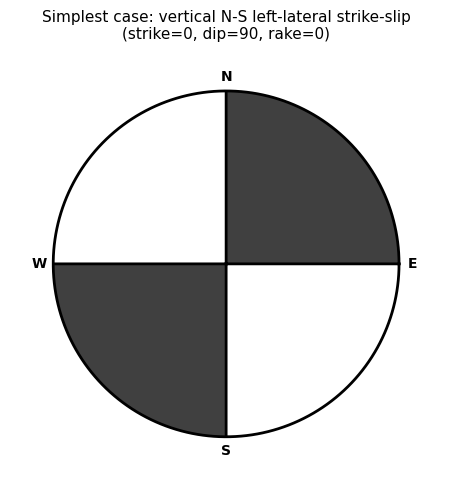

In [2]:
# The simplest beachball: vertical strike-slip fault
plot_beachball(0, 90, 0,
    title="Simplest case: vertical N-S left-lateral strike-slip\n(strike=0, dip=90, rake=0)")
plt.tight_layout()
plt.show()

Four equal quadrants — two dark (compression) and two white (dilatation). This is the basic pattern.

**Every other beachball is this same pattern, rotated.** Let's see what happens when we change strike, rake, and dip:

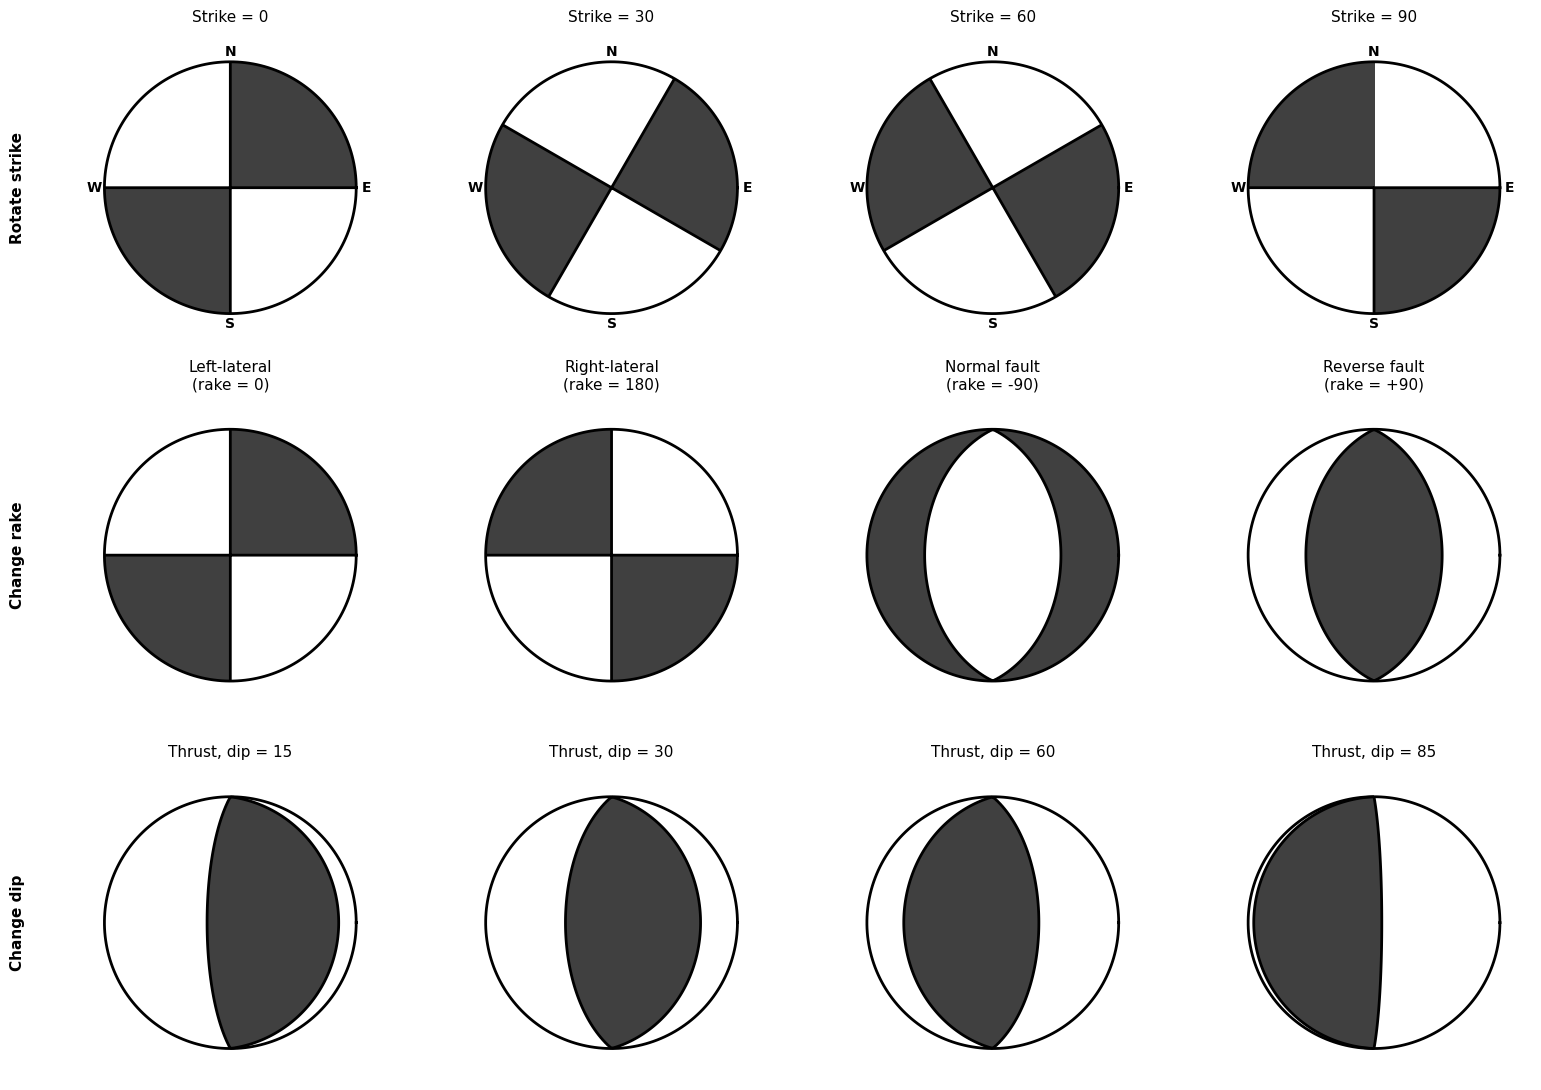

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# Row 1: Changing strike rotates the beachball
for col, strike in enumerate([0, 30, 60, 90]):
    plot_beachball(strike, 90, 0, ax=axes[0, col], title=f"Strike = {strike}")

# Row 2: Changing rake changes the fault type
for col, (s, d, r, t) in enumerate([
    (0, 90,   0, "Left-lateral\n(rake = 0)"),
    (0, 90, 180, "Right-lateral\n(rake = 180)"),
    (0, 45, -90, "Normal fault\n(rake = -90)"),
    (0, 45,  90, "Reverse fault\n(rake = +90)")]):
    plot_beachball(s, d, r, ax=axes[1, col], title=t, show_compass=False)

# Row 3: Changing dip changes the shape
for col, dip in enumerate([15, 30, 60, 85]):
    plot_beachball(0, dip, 90, ax=axes[2, col],
                  title=f"Thrust, dip = {dip}", show_compass=False)

# Row labels
for row, label in enumerate(["Rotate strike", "Change rake", "Change dip"]):
    axes[row, 0].annotate(label, xy=(-0.2, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", rotation=90, va="center")

plt.tight_layout()
plt.show()

Notice that:
- **Changing strike** (row 1) rotates the whole pattern clockwise
- **Changing rake** (row 2) transforms between fault types: strike-slip, normal, reverse
- **Changing dip** (row 3) changes the shape: low-angle thrusts have a large dark center that shrinks as dip increases

**Quick guide:** 4 equal quadrants = strike-slip, white center = normal fault, dark center = reverse fault.

**Fault plane ambiguity:** Every beachball has two nodal planes — seismic data alone cannot tell which is the actual fault. We need geological or geodetic information.

Now let's apply this to real data.

---

## 3. The 2025 Berkeley Earthquake

Same event as the magnitude lecture:

| | |
|---|---|
| **Origin time** | 2025-09-22 09:56:12 UTC |
| **Location** | 37.863°N, 122.254°W |
| **Depth** | 7.6 km |
| **Magnitude** | $M_L$ = 4.55, $M_w$ = 4.29 |
| **USGS focal mechanism** | Strike=55°, Dip=85°, Rake=10° |
| **Event page** | [nc75240492](https://earthquake.usgs.gov/earthquakes/eventpage/nc75240492/) |

In the magnitude lecture, we downloaded waveforms and measured amplitudes. Here we use **P-wave first-motion polarities** — whether the first motion is Up or Down — to determine the focal mechanism.

In [4]:
from urllib.request import urlretrieve
import xml.etree.ElementTree as ET
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.geodetics import gps2dist_azimuth

# Same earthquake parameters as the magnitude lecture
origin_time = UTCDateTime("2025-09-22T09:56:12.52")
eq_lat, eq_lon, eq_depth = 37.863, -122.254, 7.6  # km

### Step 1: Download P-wave polarities from USGS

The USGS publishes phase data in [QuakeML](https://quakeml.org/) format. Each P-wave arrival pick includes a **polarity**: positive (Up = compression) or negative (Down = dilatation).

*Run the cell below — it downloads and parses the XML data. Focus on the output summary, not the parsing code.*

In [5]:
# Download the QuakeML phase data
url = ("https://earthquake.usgs.gov/product/phase-data/"
       "nc75240492/nc/1758546070900/quakeml.xml")
urlretrieve(url, "quakeml.xml")

# Parse XML to extract polarity and arrival time at each station
tree = ET.parse("quakeml.xml")
root = tree.getroot()
ns = {"bed": "http://quakeml.org/xmlns/bed/1.2"}

polarity_picks = {}   # (network, station) -> +1 (Up) or -1 (Down)
pick_times = {}       # (network, station) -> {"ptime": ..., "loc": ...}

for pick in root.findall(".//bed:pick", ns):
    pol_el = pick.find("bed:polarity", ns)
    if pol_el is None or pol_el.text not in ("positive", "negative"):
        continue

    wf = pick.find("bed:waveformID", ns)
    net = wf.get("networkCode")
    sta = wf.get("stationCode")
    loc = wf.get("locationCode") or ""
    ptime = UTCDateTime(pick.find("bed:time/bed:value", ns).text)

    polarity_picks[(net, sta)] = 1 if pol_el.text == "positive" else -1
    pick_times[(net, sta)] = {"ptime": ptime, "loc": loc}

n_up = sum(1 for v in polarity_picks.values() if v == 1)
n_dn = sum(1 for v in polarity_picks.values() if v == -1)
print(f"Stations with P-wave polarity: {len(polarity_picks)}")
print(f"  Up (compression):  {n_up}")
print(f"  Down (dilatation): {n_dn}")

Stations with P-wave polarity: 278
  Up (compression):  129
  Down (dilatation): 149


### Step 2: Get station locations

*Run the cell below — it queries the NCEDC station web service (same data center as the magnitude lecture).*

In [6]:
# Connect to NCEDC (same as magnitude lecture)
client = Client("NCEDC")

# Group stations by network and fetch coordinates
net_stations = {}
for net, sta in polarity_picks:
    net_stations.setdefault(net, []).append(sta)

station_coords = {}
for net, stations in net_stations.items():
    inv = client.get_stations(network=net, station=",".join(stations),
        starttime=UTCDateTime("2025-09-22"), endtime=UTCDateTime("2025-09-23"),
        level="station")
    for network in inv:
        for station in network:
            station_coords[(network.code, station.code)] = (
                station.latitude, station.longitude)

print(f"Retrieved coordinates for {len(station_coords)} stations")

Retrieved coordinates for 278 stations


---

## 4. Station Map

*Run the cell below to plot all 278 stations on a map, colored by polarity.*

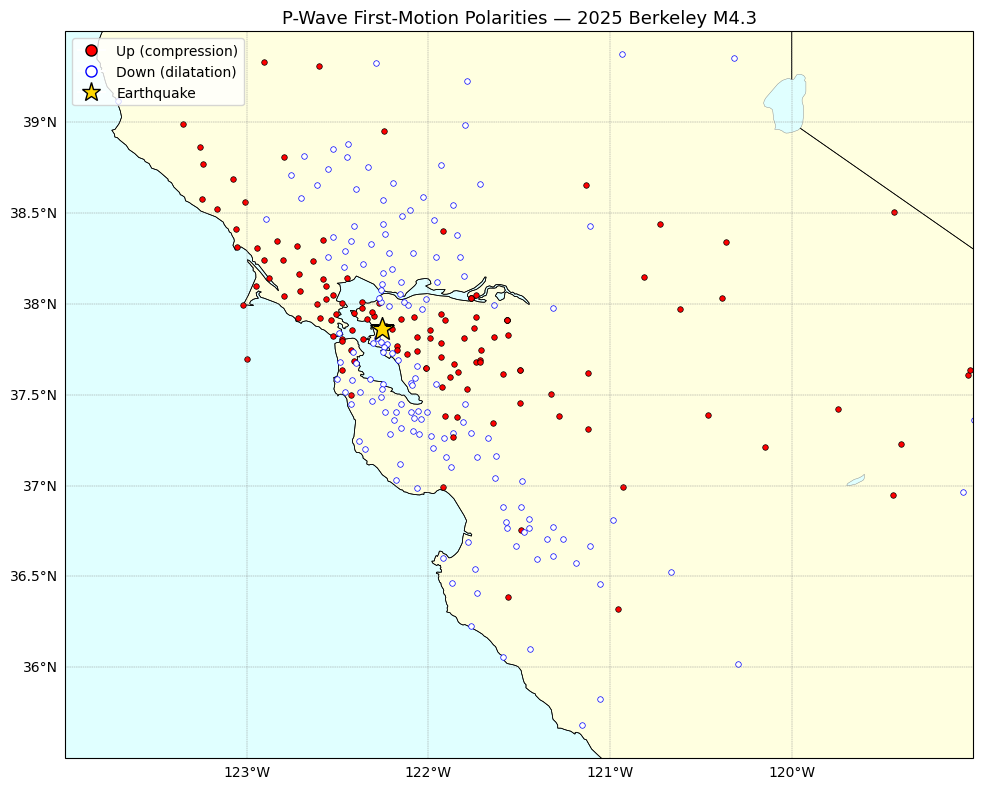

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Map extent: Northern California
ax.set_extent([-124, -119, 35.5, 39.5])

# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightyellow")
ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.LAKES, facecolor="lightcyan", edgecolor="gray", linewidth=0.3)

# Plot station polarities
for (net, sta), pol in polarity_picks.items():
    if (net, sta) not in station_coords:
        continue
    slat, slon = station_coords[(net, sta)]
    if pol == 1:
        ax.plot(slon, slat, "o", color="red", markersize=4,
                markeredgewidth=0.5, markeredgecolor="black", transform=ccrs.PlateCarree())
    else:
        ax.plot(slon, slat, "o", color="white", markersize=4,
                markeredgewidth=0.5, markeredgecolor="blue", transform=ccrs.PlateCarree())

# Earthquake epicenter
ax.plot(eq_lon, eq_lat, "*", color="gold", markersize=18,
        markeredgecolor="black", markeredgewidth=1, zorder=10, transform=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("P-Wave First-Motion Polarities \u2014 2025 Berkeley M4.3", fontsize=13)
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=8, label="Up (compression)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor="blue", markersize=8, label="Down (dilatation)"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",
           markeredgecolor="black", markersize=14, label="Earthquake"),
], loc="upper left")
plt.tight_layout()
plt.show()

278 stations across Northern California recorded this earthquake with clear first-motion polarity. The red (Up) and blue (Down) stations aren't randomly mixed — there's a spatial pattern that reflects the fault geometry.

---

## 5. What First Motions Look Like

Before analyzing all 278 stations, let's look at what P-wave first motions actually look like on seismograms. We download waveforms from 8 BK stations in different directions.

**Row A — Clear first motions:** stations far from the nodal planes, where the P-wave is strong and the polarity is obvious.

**Row B — Misfitting stations:** stations where the observed polarity **disagrees** with the USGS prediction — mostly near the nodal planes where the amplitude is weak.

*Run the cell below — it downloads waveforms and plots them. Focus on the resulting figure, not the code.*

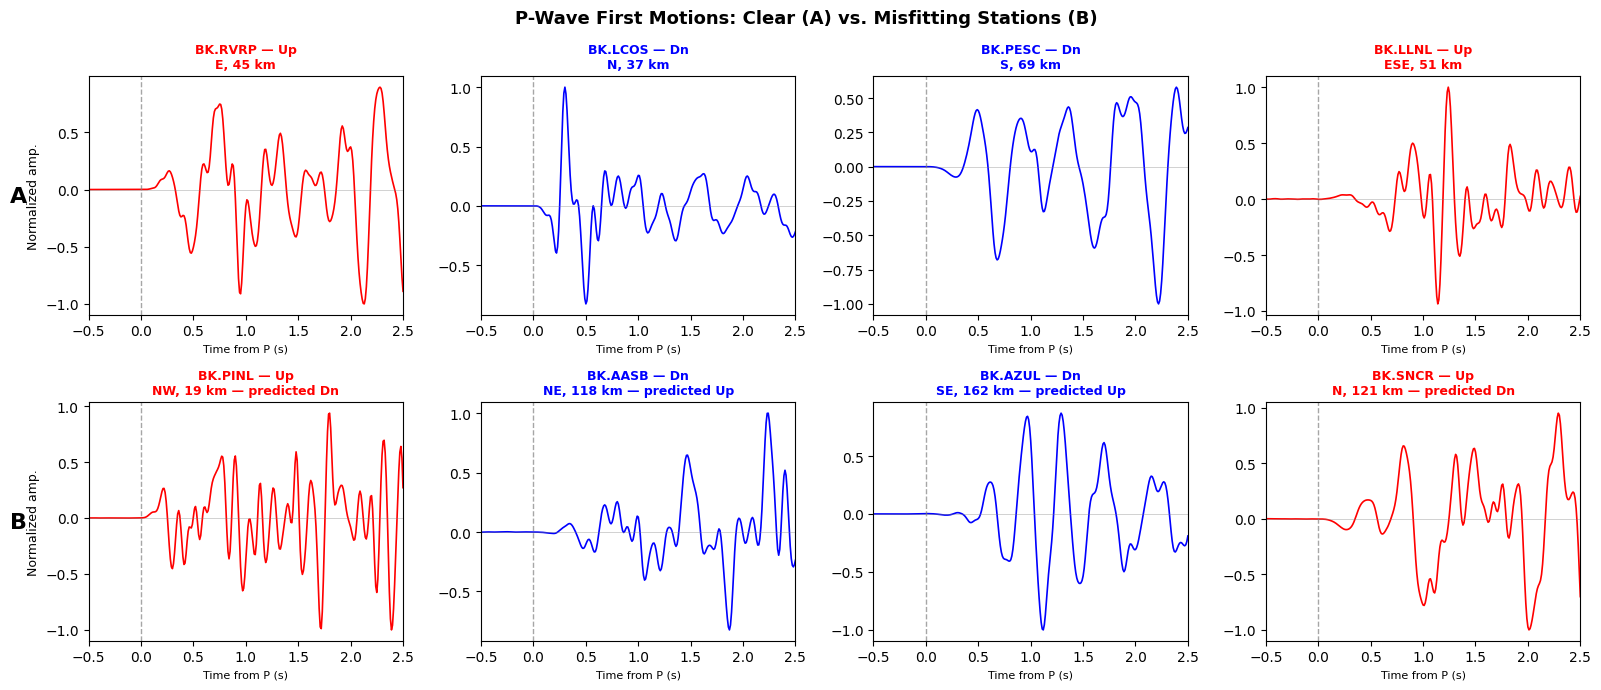

In [8]:
# 4 clear stations (far from nodal planes) + 4 misfitting stations
clear_stations = ["RVRP", "LCOS", "PESC", "LLNL"]
misfit_stations = ["PINL", "AASB", "AZUL", "SNCR"]

descriptions = {
    "RVRP": ("Up", "E, 45 km"),       "LCOS": ("Dn", "N, 37 km"),
    "PESC": ("Dn", "S, 69 km"),       "LLNL": ("Up", "ESE, 51 km"),
    "PINL": ("Up", "NW, 19 km \u2014 predicted Dn"),
    "AASB": ("Dn", "NE, 118 km \u2014 predicted Up"),
    "AZUL": ("Dn", "SE, 162 km \u2014 predicted Up"),
    "SNCR": ("Up", "N, 121 km \u2014 predicted Dn"),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for row, (station_list, row_label) in enumerate([
    (clear_stations, "A"), (misfit_stations, "B")]):
    for col, sta in enumerate(station_list):
        ax = axes[row, col]
        pol, desc = descriptions[sta]
        pick = pick_times[("BK", sta)]
        ptime, loc = pick["ptime"], pick["loc"]
        try:
            # Download vertical component around the P-wave arrival
            st = client.get_waveforms("BK", sta, loc, "HHZ", ptime-5, ptime+10)
            st.detrend("demean"); st.detrend("linear")
            st.filter("bandpass", freqmin=1.0, freqmax=10.0)

            # Cut a window around the P arrival and normalize
            tr = st[0].slice(ptime - 0.5, ptime + 2.5)
            times = tr.times(reftime=ptime)
            data = tr.data / np.max(np.abs(tr.data))

            color = "red" if pol == "Up" else "blue"
            ax.plot(times, data, color=color, linewidth=1.2)
            ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7)
            ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
            ax.set_title(f"BK.{sta} \u2014 {pol}\n{desc}",
                         fontsize=9, color=color, fontweight="bold")
        except Exception:
            ax.text(0.5, 0.5, f"{sta}: no data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10)
        ax.set_xlim(-0.5, 2.5)
        ax.set_xlabel("Time from P (s)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Normalized amp.", fontsize=9)
    axes[row, 0].annotate(row_label, xy=(-0.25, 0.5), xycoords="axes fraction",
        fontsize=16, fontweight="bold", va="center")

plt.suptitle("P-Wave First Motions: Clear (A) vs. Misfitting Stations (B)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Notice the contrast:
- **Row A:** the first swing after the P arrival (dashed line) is large and clearly **up** (red) or **down** (blue)
- **Row B:** the first motion is weaker and harder to determine — these stations are near the nodal planes where the P-wave radiation is close to zero

This is why ~15% of stations typically disagree with the best-fitting focal mechanism.

---

## 6. Project onto the Focal Sphere

To plot each polarity on a beachball diagram, we need the station's position on the **focal sphere**: its **take-off angle** and **azimuth**.

With a uniform velocity (straight rays), the take-off angle is simply:

$$i_h = \arctan\left(\frac{\Delta}{h}\right)$$

where $\Delta$ is horizontal distance and $h$ is earthquake depth. We use the **back-azimuth** to project onto the lower hemisphere.

With a uniform velocity (straight rays), the take-off angle is simply:

$$i_h = \arctan\left(\frac{\Delta}{h}\right)$$

where $\Delta$ is horizontal distance and $h$ is earthquake depth. We use the **back-azimuth** to project onto the lower hemisphere.

**Read the take-off angle calculation below** — then run the plotting cell after it.

In [9]:
def equal_area_project(takeoff_deg, azimuth_deg):
    """Equal-area projection to (x, y) on the unit circle."""
    r = np.sqrt(2) * np.sin(np.radians(takeoff_deg) / 2)
    return r * np.sin(np.radians(azimuth_deg)), r * np.cos(np.radians(azimuth_deg))

# === KEY CALCULATION ===
# For each station, compute:
#   1. Horizontal distance to the earthquake
#   2. Back-azimuth (direction from station toward earthquake)
#   3. Take-off angle = arctan(distance / depth)  [straight-ray approximation]

ray_params = []
for (net, sta), pol in polarity_picks.items():
    if (net, sta) not in station_coords:
        continue
    slat, slon = station_coords[(net, sta)]
    dist_m, az, baz = gps2dist_azimuth(eq_lat, eq_lon, slat, slon)
    dist_km = dist_m / 1000.0

    takeoff = np.degrees(np.arctan2(dist_km, eq_depth))  # <-- the key formula

    ray_params.append({"net": net, "sta": sta, "polarity": pol,
                       "takeoff": takeoff, "azimuth": baz})

print(f"Stations on focal sphere: {len(ray_params)}")

Stations on focal sphere: 278


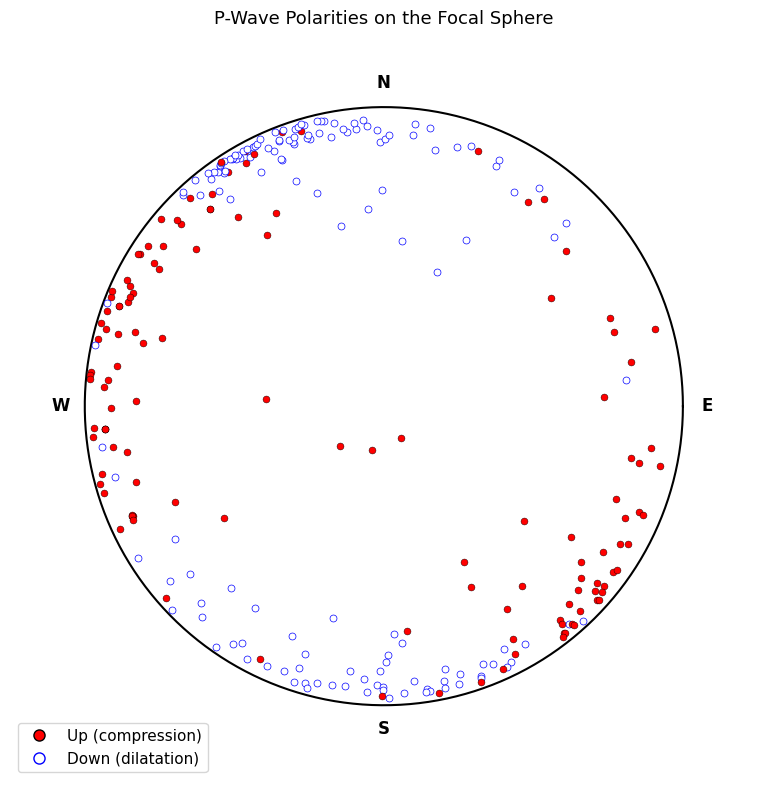

In [10]:
# Plot polarities on the lower-hemisphere equal-area projection
fig, ax = plt.subplots(figsize=(8, 8))

# Focal sphere outline and compass
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=1.5)
for ang, lbl in [(0,"N"),(90,"E"),(180,"S"),(270,"W")]:
    ax.text(1.08*np.sin(np.radians(ang)), 1.08*np.cos(np.radians(ang)),
            lbl, fontsize=12, ha="center", va="center", fontweight="bold")

# Each station: red filled = Up, blue open = Down
for r in ray_params:
    x, y = equal_area_project(r["takeoff"], r["azimuth"])
    if r["polarity"] == 1:
        ax.plot(x, y, "o", color="red", markersize=5,
                markeredgecolor="black", markeredgewidth=0.3)
    else:
        ax.plot(x, y, "o", color="white", markersize=5,
                markeredgecolor="blue", markeredgewidth=0.5)

ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("P-Wave Polarities on the Focal Sphere", fontsize=13)
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=8, label="Up (compression)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor="blue", markersize=8, label="Down (dilatation)"),
], loc="lower left", fontsize=11)
plt.tight_layout()
plt.show()

You can see two roughly perpendicular lines separating the red (Up) and blue (Down) regions — the classic four-quadrant pattern of a **strike-slip earthquake**.

---

## 7. Find the Best-Fitting Focal Mechanism

Now we search for the (strike, dip, rake) that best explains the observed polarities. For each candidate mechanism, we:

1. Build the moment tensor $\mathbf{M}$
2. Compute $A_P = \hat{\gamma}^T \mathbf{M} \hat{\gamma}$ at each station
3. Predict polarity: Up if $A_P > 0$, Down if $A_P < 0$
4. Count how many predictions match the observations

We try all combinations at 5° spacing and keep the best.

**Read the grid search loop below carefully** — this is the core algorithm.

In [11]:
# --- Helper function (just run) ---

def moment_tensor(strike_deg, dip_deg, rake_deg):
    """Build the moment tensor M from strike, dip, rake."""
    phi = np.radians(strike_deg)
    delta = np.radians(dip_deg)
    lam = np.radians(rake_deg)
    n = np.array([-np.sin(delta)*np.sin(phi),
                   np.sin(delta)*np.cos(phi), -np.cos(delta)])
    s = np.array([np.cos(lam)*np.cos(phi) + np.sin(lam)*np.cos(delta)*np.sin(phi),
                  np.cos(lam)*np.sin(phi) - np.sin(lam)*np.cos(delta)*np.cos(phi),
                 -np.sin(lam)*np.sin(delta)])
    return np.outer(s, n) + np.outer(n, s)

def predict_polarities(strike, dip, rake, gn, ge, gd):
    """Predict P-wave polarity at each station for a given mechanism."""
    M = moment_tensor(strike, dip, rake)
    amp = (M[0,0]*gn**2 + M[1,1]*ge**2 + M[2,2]*gd**2
           + 2*M[0,1]*gn*ge + 2*M[0,2]*gn*gd + 2*M[1,2]*ge*gd)
    return np.sign(amp)

# --- Pre-compute station ray directions ---

to_rad = np.radians([r["takeoff"] for r in ray_params])
az_rad = np.radians([r["azimuth"] for r in ray_params])
observed = np.array([r["polarity"] for r in ray_params])

gn = np.sin(to_rad) * np.cos(az_rad)  # North component
ge = np.sin(to_rad) * np.sin(az_rad)  # East component
gd = np.cos(to_rad)                    # Down component

# === GRID SEARCH (the key algorithm) ===
# Try every combination of strike, dip, rake.
# For each one, predict the polarity at every station and count matches.

best_score = 0
best_fm = (0, 0, 0)

for strike in range(0, 360, 5):        # 72 values
    for dip in range(5, 91, 5):         # 18 values
        for rake in range(-180, 181, 10):  # 37 values
            predicted = predict_polarities(strike, dip, rake, gn, ge, gd)
            score = np.sum(predicted == observed)

            if score > best_score:
                best_score = score
                best_fm = (strike, dip, rake)

print(f"Best-fitting focal mechanism:")
print(f"  Strike = {best_fm[0]}")
print(f"  Dip    = {best_fm[1]}")
print(f"  Rake   = {best_fm[2]}")
print(f"  Matching stations: {best_score}/{len(ray_params)} "
      f"({100*best_score/len(ray_params):.1f}%)")

Best-fitting focal mechanism:
  Strike = 145
  Dip    = 65
  Rake   = 170
  Matching stations: 241/278 (86.7%)


Our grid search finds a mechanism consistent with **right-lateral strike-slip** on a **NW–SE trending fault** — as expected for the Hayward Fault.

The ~87% match rate is typical: stations near the nodal planes often have ambiguous polarities, and our simplified uniform velocity model introduces some errors in the take-off angles.

---

## 8. Comparing with the USGS

The USGS determined the focal mechanism using a realistic 1D velocity model and 266 stations. Let's overlay both solutions on the polarity data:

*Run the cell below to see the comparison.*

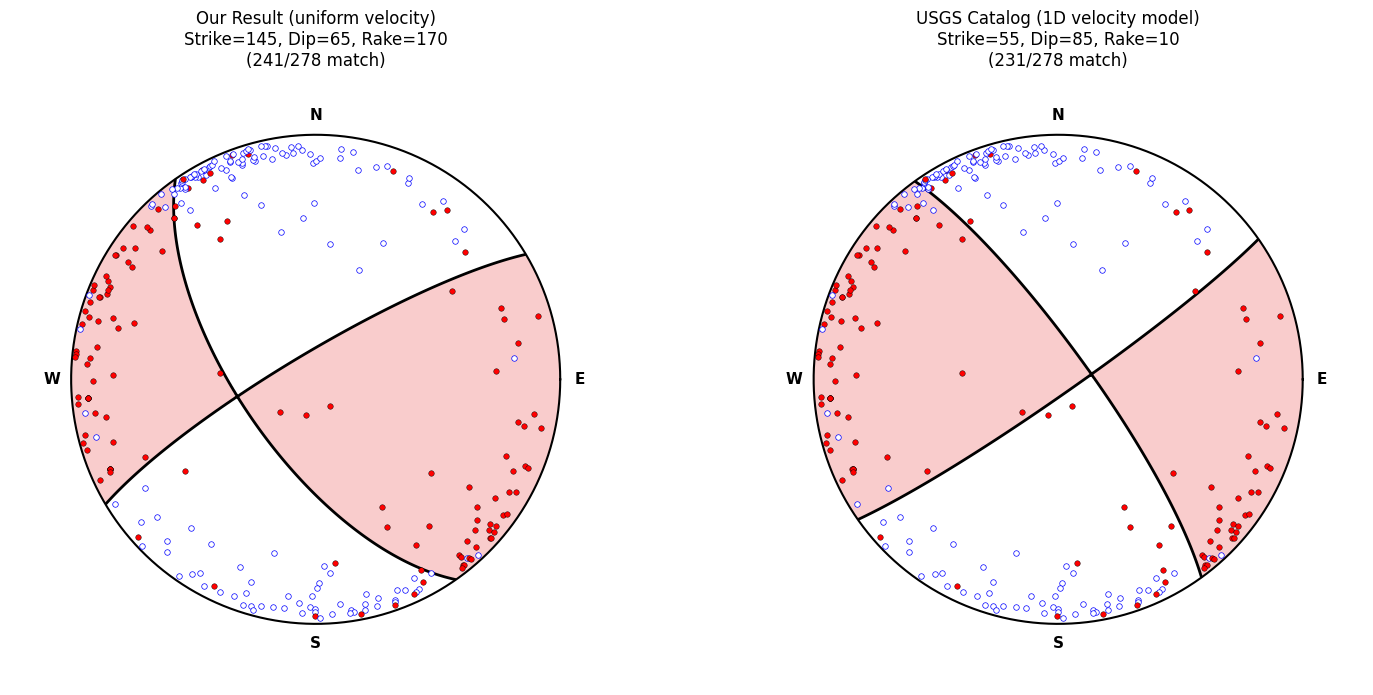

In [12]:
# --- Plotting code (just run) ---

# Pre-compute radiation pattern grid for beachball overlay
n_grid = 300
az_g = np.linspace(0, 360, n_grid)
to_g = np.linspace(0, 90, n_grid // 2)
AZ_g, TO_g = np.meshgrid(az_g, to_g)
R_g = np.sqrt(2) * np.sin(np.radians(TO_g) / 2)
X_g, Y_g = R_g * np.sin(np.radians(AZ_g)), R_g * np.cos(np.radians(AZ_g))

# Grid of ray direction components for computing radiation
gn_g = np.sin(np.radians(TO_g)) * np.cos(np.radians(AZ_g))
ge_g = np.sin(np.radians(TO_g)) * np.sin(np.radians(AZ_g))
gd_g = np.cos(np.radians(TO_g))

def radiation_on_grid(strike, dip, rake):
    """Compute radiation amplitude on the focal sphere grid."""
    M = moment_tensor(strike, dip, rake)
    return (M[0,0]*gn_g**2 + M[1,1]*ge_g**2 + M[2,2]*gd_g**2
            + 2*M[0,1]*gn_g*ge_g + 2*M[0,2]*gn_g*gd_g + 2*M[1,2]*ge_g*gd_g)

def polarity_score(strike, dip, rake):
    """Count how many station polarities match a given mechanism."""
    M = moment_tensor(strike, dip, rake)
    amp = (M[0,0]*gn**2 + M[1,1]*ge**2 + M[2,2]*gd**2
           + 2*M[0,1]*gn*ge + 2*M[0,2]*gn*gd + 2*M[1,2]*ge*gd)
    return int(np.sum(np.sign(amp) == observed))

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
theta = np.linspace(0, 2*np.pi, 200)

solutions = [
    (best_fm, "Our Result (uniform velocity)"),
    ((55, 85, 10), "USGS Catalog (1D velocity model)"),
]

for ax, ((s, d, r), label) in zip(axes, solutions):
    # Beachball overlay
    AMP = radiation_on_grid(s, d, r)
    ax.contourf(X_g, Y_g, AMP, levels=[-1, 0, 1],
                colors=["white", "lightcoral"], alpha=0.4)
    ax.contour(X_g, Y_g, AMP, levels=[0], colors="black", linewidths=2)
    ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=1.5)

    # Compass labels
    for ang, lbl in [(0,"N"),(90,"E"),(180,"S"),(270,"W")]:
        ax.text(1.08*np.sin(np.radians(ang)), 1.08*np.cos(np.radians(ang)),
                lbl, fontsize=11, ha="center", va="center", fontweight="bold")

    # Station polarities
    for rp in ray_params:
        x, y = equal_area_project(rp["takeoff"], rp["azimuth"])
        if rp["polarity"] == 1:
            ax.plot(x, y, "o", color="red", markersize=4,
                    markeredgecolor="black", markeredgewidth=0.3)
        else:
            ax.plot(x, y, "o", color="white", markersize=4,
                    markeredgecolor="blue", markeredgewidth=0.5)

    score = polarity_score(s, d, r)
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{label}\nStrike={s}, Dip={d}, Rake={r}\n"
                 f"({score}/{len(ray_params)} match)", fontsize=12)

plt.tight_layout()
plt.show()

Both solutions show the same thing: **right-lateral strike-slip** on a fault trending NW–SE. The small differences come from our simplified velocity model — with a realistic 1D model, the take-off angles would be slightly different.

---

## 9. Discussion

**What we found:** A right-lateral strike-slip mechanism on a NW–SE trending fault — consistent with the **Hayward Fault** (strike ≈ 325°).

**Fault plane ambiguity:** The focal mechanism has two nodal planes. We know the Hayward Fault is the actual fault plane because it has been mapped geologically and geodetically.

**Why ~15% misfits?** Stations near the nodal planes have weak P-wave radiation, making polarity picks uncertain. Our simplified velocity model also introduces errors in take-off angles for distant stations.

---

## Summary

In the magnitude lecture, we measured *how big* this earthquake was ($M_L \approx 4.6$). Now we've determined *how it ruptured*:

| Step | What we did |
|------|-------------|
| Beachball theory | Moment tensor → radiation pattern → beachball diagram |
| Download data | USGS QuakeML: 278 stations with P-wave polarity |
| Waveform examples | Clear first motions vs. misfitting stations near nodal planes |
| Focal sphere | Projected polarities using uniform-velocity take-off angles |
| Grid search | Best-fitting strike, dip, rake from polarity matching |
| Interpretation | Right-lateral strike-slip on the Hayward Fault |